# TradeWatch — Anomaly Detection Analysis

**Exploratory data analysis + model evaluation** for the TradeWatch surveillance
engine. This notebook is the data-scientist's view of the same detection problem
the real-time engine solves on the hot path:

1. build a labelled trade tape (normal flow + injected market abuse),
2. engineer a leakage-safe feature matrix (the exact features the engine sees),
3. explore class balance and feature separability,
4. train supervised + unsupervised models on a time-ordered split,
5. evaluate with ROC / PR curves, a confusion matrix and feature importances.

> Reproduce end-to-end from the CLI: `tradewatch train --trades 40000`


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
from sklearn.metrics import (roc_curve, precision_recall_curve, auc,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

from tradewatch.sources import MarketSimulator
from tradewatch.ml.features import FeatureBuilder, FEATURE_NAMES

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
RANDOM_SEED = 7

## 1. Build a labelled dataset
Stream simulated trades and engineer features leakage-safely (features for trade *t* use only trades before *t*).

In [2]:
sim = MarketSimulator(symbols=["AAPL","MSFT","BTC-USD","ETH-USD","TSLA"],
                      anomaly_rate=0.02, seed=RANDOM_SEED)
builder = FeatureBuilder()
rows, labels = [], []
for trade, label in sim.labeled_batch(20000):
    rows.append(builder.transform_one(trade))
    labels.append(0 if label is None else 1)

df = pd.DataFrame(np.vstack(rows), columns=FEATURE_NAMES)
df["label"] = labels
print(f"{len(df):,} trades, {df.label.sum():,} anomalies "
      f"({df.label.mean():.2%} positive)")
df.head()

20,000 trades, 4,281 anomalies (21.40% positive)


,price_z,price_pct_move,size_vs_median,trades_in_5s,side_imbalance,notional_log,spread_from_last,qty_z,label
0,0.0,0.000000,1.000000,0.0,0.0,11.322685,0.000000,0.0,0
1,0.0,0.000000,1.000000,0.0,0.0,11.371445,0.000000,0.0,0
2,0.0,0.000000,1.000000,0.0,0.0,15.280262,0.000000,0.0,0
3,0.0,0.002497,0.740868,1.0,-1.0,14.982823,0.002497,0.0,0
4,0.0,0.000000,1.000000,0.0,0.0,9.477103,0.000000,0.0,0


## 2. Class balance & feature separability
Surveillance data is highly imbalanced — that is why we care about PR-AUC, not just accuracy.

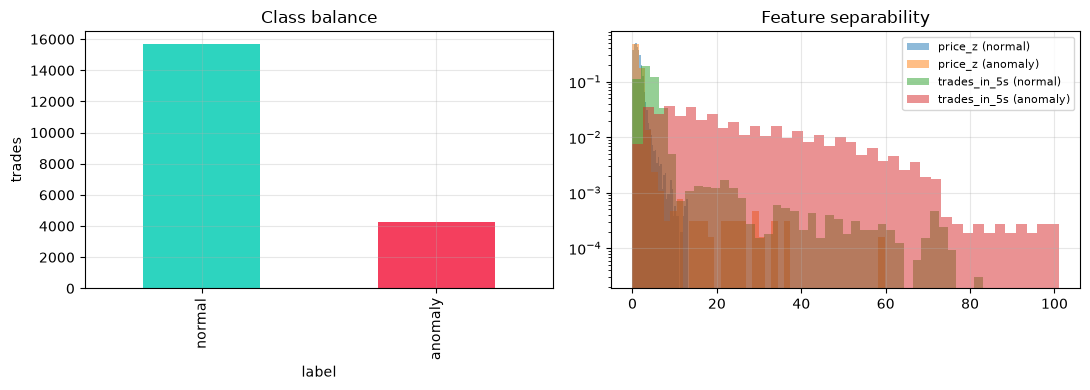

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df.label.value_counts().rename({0:"normal",1:"anomaly"}).plot.bar(
    ax=ax[0], color=["#2dd4bf","#f43f5e"])
ax[0].set_title("Class balance"); ax[0].set_ylabel("trades")
for f in ["price_z","trades_in_5s"]:
    ax[1].hist(df[df.label==0][f], bins=40, alpha=0.5, label=f"{f} (normal)", density=True)
    ax[1].hist(df[df.label==1][f], bins=40, alpha=0.5, label=f"{f} (anomaly)", density=True)
ax[1].set_title("Feature separability"); ax[1].set_yscale("log"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

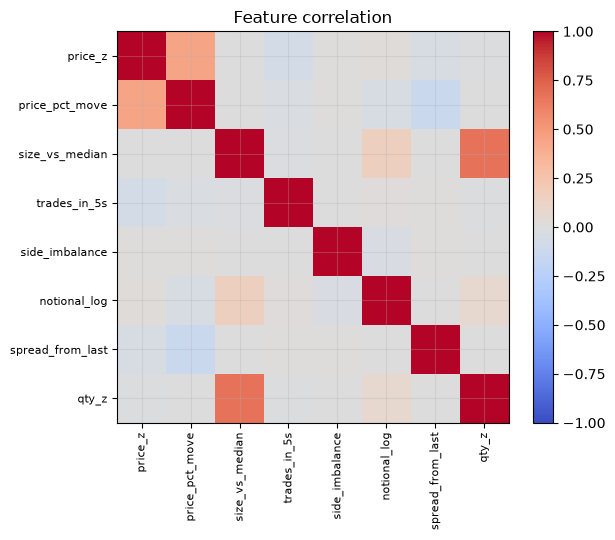

In [4]:
# Correlation of engineered features
corr = df[FEATURE_NAMES].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_NAMES))); ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURE_NAMES))); ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
fig.colorbar(im, fraction=0.046); ax.set_title("Feature correlation"); plt.tight_layout(); plt.show()

## 3. Train models on a time-ordered split
No shuffling — this is a stream, so we train on the past and test on the future.

In [5]:
X = df[FEATURE_NAMES].values; y = df.label.values
split = int(len(X) * 0.7)
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]

clf = GradientBoostingClassifier(random_state=RANDOM_SEED).fit(X_tr, y_tr)
clf_score = clf.predict_proba(X_te)[:, 1]

iso = IsolationForest(contamination=0.02, n_estimators=200,
                      random_state=RANDOM_SEED).fit(X_tr)
iso_score = -iso.decision_function(X_te)
print("trained gradient boosting (supervised) + isolation forest (unsupervised)")

trained gradient boosting (supervised) + isolation forest (unsupervised)


## 4. ROC & Precision-Recall curves

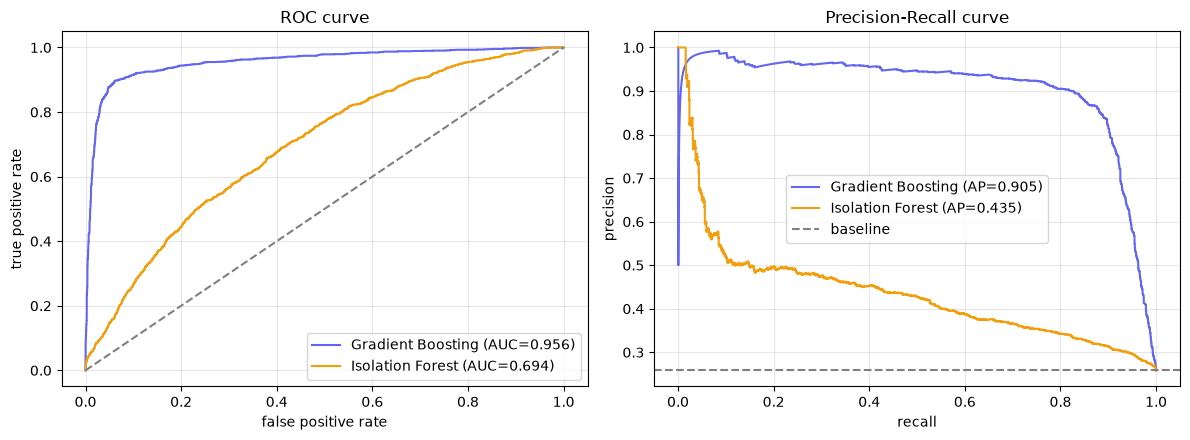

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, score, c in [("Gradient Boosting", clf_score, "#6366f1"),
                       ("Isolation Forest", iso_score, "#f59e0b")]:
    fpr, tpr, _ = roc_curve(y_te, score)
    ax[0].plot(fpr, tpr, color=c, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, score)
    ax[1].plot(rc, pr, color=c, label=f"{name} (AP={auc(rc,pr):.3f})")
ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title("ROC curve")
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate"); ax[0].legend()
ax[1].axhline(y_te.mean(), ls="--", color="gray", label="baseline")
ax[1].set_title("Precision-Recall curve"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Confusion matrix & classification report (champion)

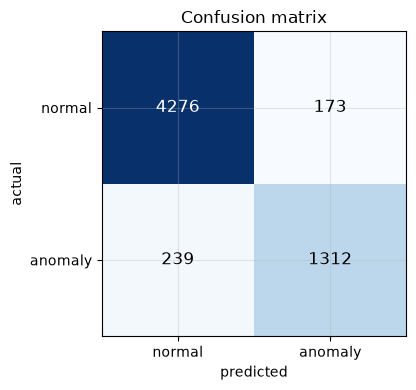

              precision    recall  f1-score   support

      normal      0.947     0.961     0.954      4449
     anomaly      0.884     0.846     0.864      1551

    accuracy                          0.931      6000
   macro avg      0.915     0.904     0.909      6000
weighted avg      0.931     0.931     0.931      6000



In [7]:
y_pred = (clf_score >= 0.5).astype(int)
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v}", ha="center", va="center",
            color="white" if v > cm.max()/2 else "black", fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(["normal","anomaly"])
ax.set_yticks([0,1]); ax.set_yticklabels(["normal","anomaly"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Confusion matrix")
plt.tight_layout(); plt.show()
print(classification_report(y_te, y_pred, target_names=["normal","anomaly"], digits=3))

## 6. Feature importance (permutation)
Which engineered signals actually drive the model's decisions.

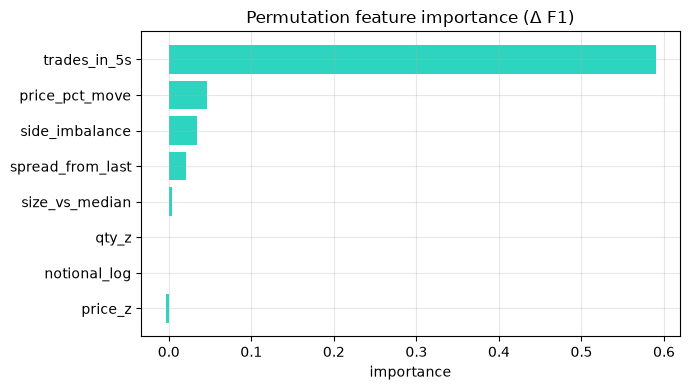

In [8]:
imp = permutation_importance(clf, X_te, y_te, n_repeats=5,
                             random_state=RANDOM_SEED, scoring="f1")
order = np.argsort(imp.importances_mean)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([FEATURE_NAMES[i] for i in order],
        imp.importances_mean[order], color="#2dd4bf")
ax.set_title("Permutation feature importance (Δ F1)"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

## Conclusion

- The engineered features separate abuse from normal flow well: the supervised
  gradient-booster reaches a strong ROC-AUC / PR-AUC on a *future* test window.
- `trades_in_5s`, `price_pct_move` and `price_z` carry most of the signal —
  consistent with the rule engine's velocity, price-spike and z-score detectors.
- The unsupervised Isolation Forest is weaker alone (no labels) but valuable in
  production where labels are scarce and novel patterns appear.

The offline model complements the real-time rules: the rules give explainable,
sub-millisecond decisions on the hot path; this model backtests thresholds and
captures multivariate structure. Promote it via `tradewatch train`, which logs
runs to MLflow and writes a model card.
